In [10]:
import os 
import sys 
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import shutil
import cv2

In [11]:
RAW_DIR = '../dataset/00_raw_data/lot1'
TEST_DIR = '../dataset/preprocessed_test/lot1'
PROCESSED_DIR = '../dataset/01_processed/lot1'

os.makedirs(f"{TEST_DIR}/originals", exist_ok=True)
os.makedirs(f"{TEST_DIR}/masks", exist_ok=True)
os.makedirs(f"{TEST_DIR}/resized", exist_ok=True)
os.makedirs(f"{PROCESSED_DIR}", exist_ok=True)

In [12]:
def explore_raw_dataset():
    if not os.path.exists(RAW_DIR):
        return []
    
    all_files = os.listdir(RAW_DIR)
    image_files = [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    print(f"{RAW_DIR}:")
    print(f"Number of file {len(all_files)}")
    print(f"   - Images: {len(image_files)}")
    print(f"   - others: {len(all_files) - len(image_files)}")
    
    if image_files:
        sample_path = os.path.join(RAW_DIR, image_files[0])
        with Image.open(sample_path) as img:
            print(f"   - Resolution: {img.size}")
            print(f"   - Format: {img.mode}")
    
    return image_files

raw_images = explore_raw_dataset()

../dataset/00_raw_data/lot1:
Number of file 81
   - Images: 81
   - others: 0
   - Resolution: (4032, 3024)
   - Format: RGB


In [13]:
def setup_test_images(num_images=3):
    if not raw_images:
        return []
    
    test_files = raw_images[:num_images]
    print(f"Copying {len(test_files)} images for testing...")
    
    for filename in test_files:
        src = os.path.join(RAW_DIR, filename)
        dst = os.path.join(f"{TEST_DIR}/originals", filename)
        shutil.copy2(src, dst)
        print(f"   Copied {filename}")
    
    return test_files

test_files = setup_test_images(3)
print(f"Test images: {test_files}")

Copying 3 images for testing...
   Copied IMG_0389.JPG
   Copied IMG_0404.JPG
   Copied IMG_0410.JPG
Test images: ['IMG_0389.JPG', 'IMG_0404.JPG', 'IMG_0410.JPG']


1024px: (1024, 768) - 181.3KB
1365px: (1365, 1023) - 297.3KB
1536px: (1536, 1152) - 363.1KB
768px: (768, 576) - 110.2KB


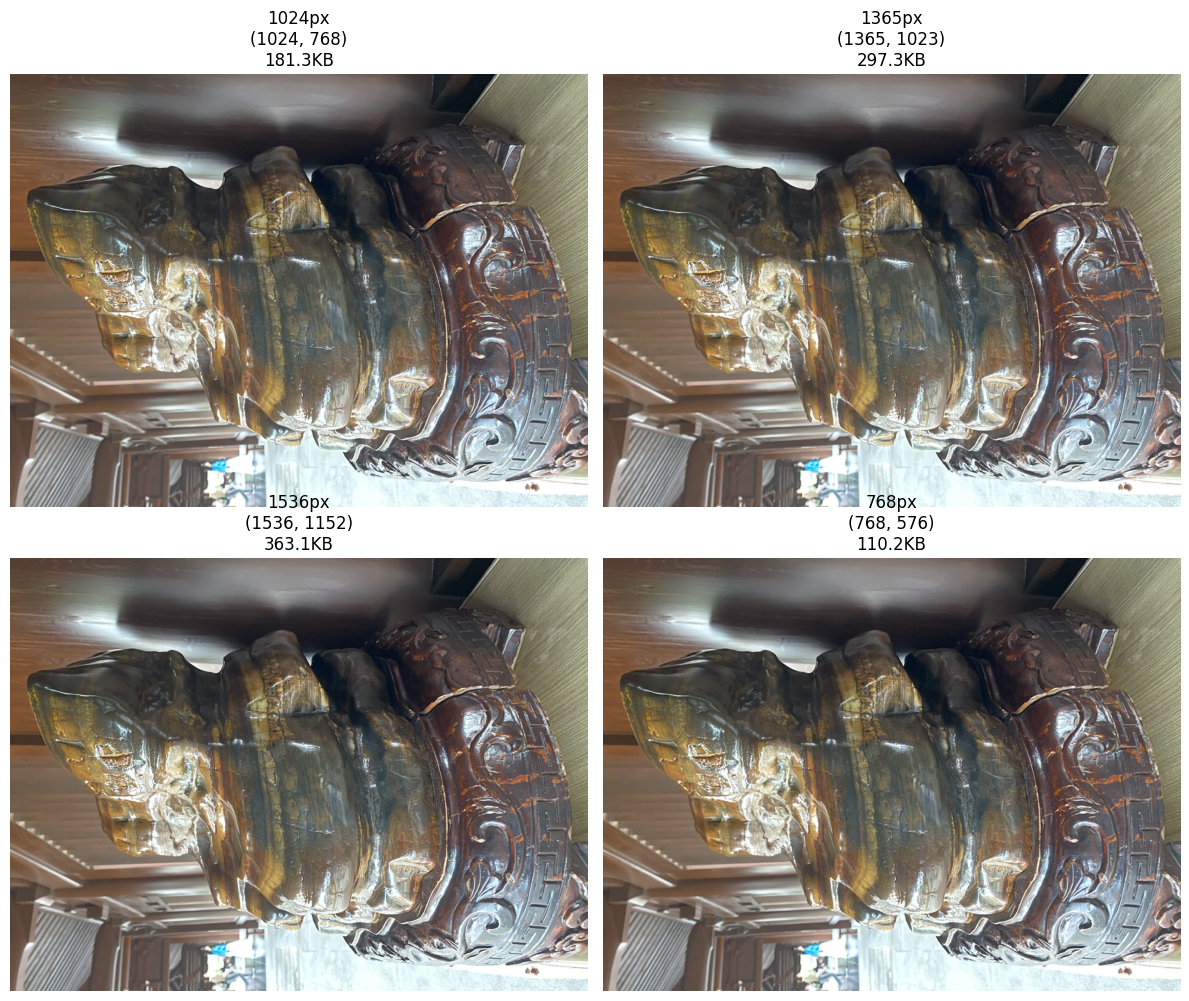

In [15]:
def test_resize_strategies():
    """Test different resizing methods"""
    filename = test_files[0]
    input_path = os.path.join(f"{TEST_DIR}/originals", filename)
    
    strategies = {
        '1024px': 1024,
        '1365px': 1365, 
        '1536px': 1536,
        '768px': 768
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, (name, max_size) in enumerate(strategies.items()):
        with Image.open(input_path) as img:
            width, height = img.size
            ratio = width / height
            
            if width > height:  # Landscape
                new_width = min(width, max_size)
                new_height = int(new_width / ratio)
            else:  # Portrait
                new_height = min(height, max_size)
                new_width = int(new_height * ratio)
            
            img_resized = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
            output_path = os.path.join(f"{TEST_DIR}/resized", f"{name}_{filename}")
            img_resized.save(output_path, quality=85, optimize=True)
            
            # Display
            axes[i].imshow(img_resized)
            axes[i].set_title(f"{name}\n{img_resized.size}\n{os.path.getsize(output_path)/1024:.1f}KB")
            axes[i].axis('off')
            
            print(f"{name}: {img_resized.size} - {os.path.getsize(output_path)/1024:.1f}KB")
    
    plt.tight_layout()
    plt.show()

test_resize_strategies()

Testing manual masking...
Error 1024px: name 'ImageDraw' is not defined
Error 1365px: name 'ImageDraw' is not defined
Error 1536px: name 'ImageDraw' is not defined
Error 768px: name 'ImageDraw' is not defined


FileNotFoundError: [Errno 2] No such file or directory: '../dataset/preprocessed_test/lot1/comparison/masking_results.jpg'

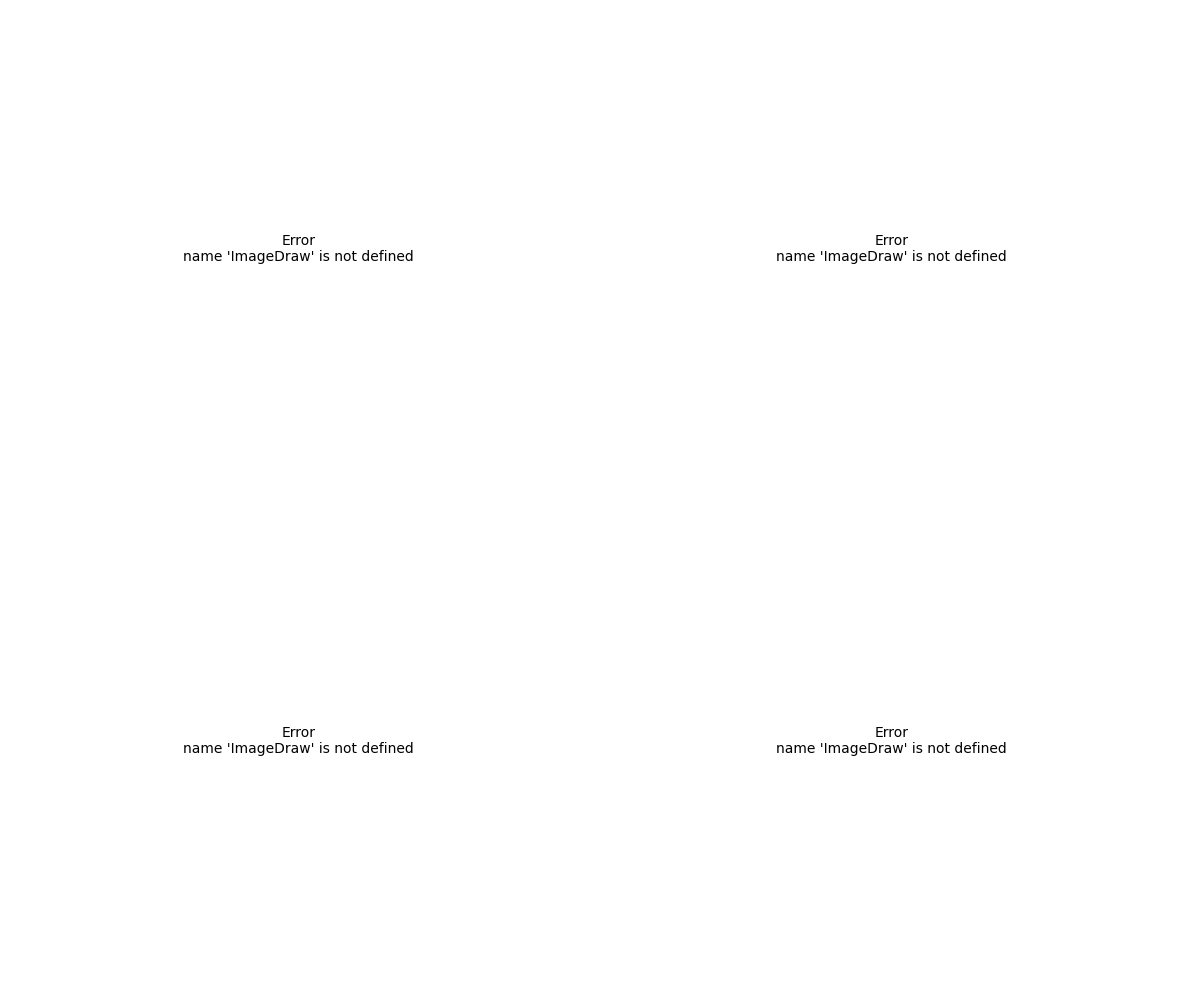

In [16]:
# Cell 6: Test manual masking
def test_manual_masking():
    """Test manual masking on different sizes"""
    print("Testing manual masking...")
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    resize_strategies = ['1024px', '1365px', '1536px', '768px']
    
    for i, strategy in enumerate(resize_strategies):
        input_filename = f"{strategy}_{test_files[0]}"
        input_path = os.path.join(f"{TEST_DIR}/resized", input_filename)
        output_path = os.path.join(f"{TEST_DIR}/masked", f"masked_{input_filename.replace('.jpg', '.png')}")
        
        try:
            # Open and process image for manual masking
            img = Image.open(input_path)
            
            # Convert to RGBA if not already
            if img.mode != 'RGBA':
                img = img.convert('RGBA')
            
            # Create a simple manual mask (example: keep center region, transparent edges)
            # This is a basic example - you would implement your actual masking logic here
            width, height = img.size
            mask = Image.new('L', (width, height), 0)  # Start with all transparent
            
            # Create a simple rectangular mask in the center (replace with your actual masking logic)
            margin_w = width // 4
            margin_h = height // 4
            mask_region = (margin_w, margin_h, width - margin_w, height - margin_h)
            
            # Draw a white rectangle for the mask area
            draw = ImageDraw.Draw(mask)
            draw.rectangle(mask_region, fill=255)
            
            # Apply the mask
            img.putalpha(mask)
            
            # Save the result
            img.save(output_path, 'PNG')
            
            # Display
            axes[i].imshow(img)
            axes[i].set_title(f"{strategy} + Manual Mask\n{img.size}\n{img.mode}")
            axes[i].axis('off')
            
            print(f"{strategy}: {img.mode} - {os.path.getsize(output_path)/1024:.1f}KB")
            
        except Exception as e:
            print(f"Error {strategy}: {e}")
            axes[i].text(0.5, 0.5, f"Error\n{e}", ha='center', va='center', transform=axes[i].transAxes)
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{TEST_DIR}/comparison/masking_results.jpg", dpi=150, bbox_inches='tight')
    plt.show()

test_manual_masking()

Testing manual masking...
1024px: RGBA - 1267.4KB
1365px: RGBA - 2104.3KB
1536px: RGBA - 2590.5KB
768px: RGBA - 755.7KB


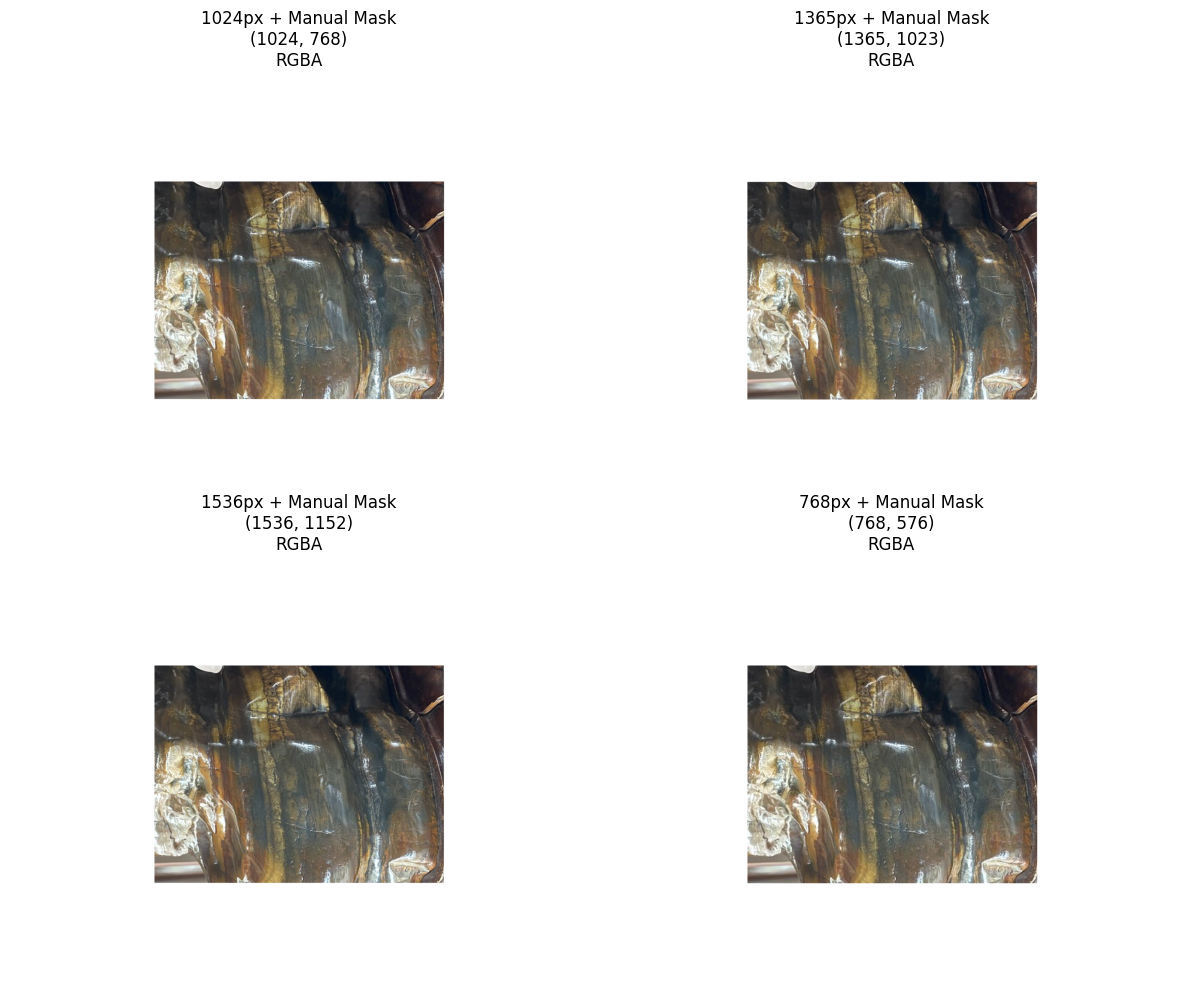

In [18]:
# Cell 6: Test manual masking
def test_manual_masking():
    """Test manual masking on different sizes"""
    print("Testing manual masking...")
    
    # Create output directory if it doesn't exist
    os.makedirs(f"{TEST_DIR}/comparison", exist_ok=True)
    os.makedirs(f"{TEST_DIR}/masked", exist_ok=True)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    resize_strategies = ['1024px', '1365px', '1536px', '768px']
    
    for i, strategy in enumerate(resize_strategies):
        input_filename = f"{strategy}_{test_files[0]}"
        input_path = os.path.join(f"{TEST_DIR}/resized", input_filename)
        output_path = os.path.join(f"{TEST_DIR}/masked", f"masked_{input_filename.replace('.jpg', '.png')}")
        
        try:
            # Open and process image for manual masking
            img = Image.open(input_path)
            
            # Convert to RGBA if not already
            if img.mode != 'RGBA':
                img = img.convert('RGBA')
            
            # Create a simple manual mask (example: keep center region, transparent edges)
            # This is a basic example - you would implement your actual masking logic here
            width, height = img.size
            mask = Image.new('L', (width, height), 0)  # Start with all transparent
            
            # Create a simple rectangular mask in the center (replace with your actual masking logic)
            margin_w = width // 4
            margin_h = height // 4
            mask_region = (margin_w, margin_h, width - margin_w, height - margin_h)
            
            # Draw a white rectangle for the mask area
            from PIL import ImageDraw  # Import ImageDraw here
            draw = ImageDraw.Draw(mask)
            draw.rectangle(mask_region, fill=255)
            
            # Apply the mask
            img.putalpha(mask)
            
            # Save the result
            img.save(output_path, 'PNG')
            
            # Display
            axes[i].imshow(img)
            axes[i].set_title(f"{strategy} + Manual Mask\n{img.size}\n{img.mode}")
            axes[i].axis('off')
            
            print(f"{strategy}: {img.mode} - {os.path.getsize(output_path)/1024:.1f}KB")
            
        except Exception as e:
            print(f"Error {strategy}: {e}")
            axes[i].text(0.5, 0.5, f"Error\n{e}", ha='center', va='center', transform=axes[i].transAxes)
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{TEST_DIR}/comparison/masking_results.jpg", dpi=150, bbox_inches='tight')
    plt.show()

test_manual_masking()